### <h1 align="center">Fig. 2f, 2j: Quantification of the spindle elongation rate and chromosome segregation speed</h1>

This notebook is used to analyze the rate at which the spindle length elongates and the speed at which the chromosomes segregate at different embryonic cell stage as a function of the cell size. This aforementioned analysis is implemented for the three analyzed embryonic conditions (Wild-type, Big: C27D9.1, Small: ani-2). The output is visualized on a scattered plot. The plot from each embryonic condition is labelled with a unique color as shown in the plot output.

**`Input`:**

The input data file is a *.CSV* file for each embryonic condition containing a dynamic analysis summary of all the analyzed experimental dataset. The columns header of each file should look like the following example table below:


|Cell	Vol (µm³) | std_Vol | Cell length (µm) | '...' | segregation speed chromosome-to-chromosome (µm/min) | segregation speed chromosome-to-chromosome std |
| :-----: | :-----: | :-----: |:-----:| :-----: |:----------------------------------------------:|
| `num` | `num` | `num` | `num` | `num` |                     `num`                      |
| `...` | `...` | `...` | `...` | `...` |

**`Output`:**

*.PNG* file containing a combined plots for Rate spindle length elongation and chromosome segregation speed each.

In [29]:
# library packages
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import make_interp_spline

In [30]:
# input folder
folder = r'E:\data\Analysis Data\01_python_analysis\input'
fileTable = os.listdir(folder)

# output folder
save_files = r'E:\data\Analysis Data\01_python_analysis\output_new'

#### Load input files

In [31]:
file_list = {}
file_container = [
    '00_Dynamics_analysis_summary (WT).csv',
    '01_Dynamics_analysis_summary (small).csv',
    '01_Dynamics_analysis_summary (big).csv'
]

for file in fileTable:
    filepath = os.path.join(folder, file)
    filename = os.path.basename(filepath)

    if filename in file_container:
        try:
            df = pd.read_csv(filepath, index_col=None, encoding='utf-8')
        except:
            df = pd.read_csv(filepath, index_col=None, encoding='cp1252')

        key = filename.replace('.csv', '')
        file_list[key] = df

In [32]:
# assign variables to the files in the file_list
df_WT = file_list['00_Dynamics_analysis_summary (WT)']
df_small = file_list['01_Dynamics_analysis_summary (small)']
df_big = file_list['01_Dynamics_analysis_summary (big)']

In [33]:
# check if files are loaded correctly
df_WT.head(2)
# df_small.head(3)

,Cell,Vol (µm³),std_Vol,Cell length (µm),Error propagation,Initial pole-to-pole (µm),Initial pole-to-pole std,Final pole-to-pole (µm),Final pole-to-pole std,Final chromosome-to-chromosome (µm),Final chromosome-to-chromosome std,Final pole-to-chromosome (µm),Final pole-to-chromosome std,Metaphase pole-to-pole (µm),Metaphase pole-to-pole std,Elongation rate pole-to-pole (µm/min),Elongation rate pole-to-pole std,segregation speed chromosome-to-chromosome (µm/min),segregation speed chromosome-to-chromosome std
0,2-cell,11337.002500,2597.081034,22.464637,1.715400,7.375582,1.912597,20.461335,1.518879,6.891947,0.727578,5.746507,0.382069,13.265341,0.772426,3.685459,0.801415,13.688664,8.892648
1,4-cell,5499.324167,1455.039123,17.651019,1.556732,8.310042,0.872522,17.910128,1.434671,7.143993,0.525912,4.837708,0.516312,11.265940,1.055440,4.027685,0.652062,13.099400,3.046818


#### Define plot parameters

In [34]:
'''Wild type parameters'''
x_WT = df_WT['Cell length (µm)'] # WT cell length
y_WT_pp = df_WT['Final pole-to-pole (µm)'] # WT pole-to-pole final distance
y_WT_cc = df_WT['Final chromosome-to-chromosome (µm)'] # WT chromosome-to-chromosome final distance
y_WT_pp_elong = df_WT['Elongation rate pole-to-pole (µm/min)'] # elongation rate
y_WT_cc_segreg = df_WT['segregation speed chromosome-to-chromosome (µm/min)'] # segregation speed
x_WT_err = df_WT['Error propagation'] # cell length error of propagation
y_WT_pp_err = df_WT['Final pole-to-pole std'] # std for pole-to-pole final distance
y_WT_cc_err = df_WT['Final chromosome-to-chromosome std'] # std for chromosome-to-chromosome final distance
y_WT_pp_elong_err = df_WT['Elongation rate pole-to-pole std'] # std for elongation rate 
y_WT_cc_segreg_err = df_WT['segregation speed chromosome-to-chromosome std'] # std for segregation speed

In [35]:
'''Small embryo parameters'''
x_small = df_small['Cell length (µm)'] # small cell length
y_small_pp = df_small['Final pole-to-pole (µm)'] # small pole-to-pole final distance
y_small_cc = df_small['Final chromosome-to-chromosome (µm)'] # small chromosome-to-chromosome final distance
y_small_pp_elong = df_small['Elongation rate pole-to-pole (µm/min)'] # elongation rate
y_small_cc_segreg = df_small['segregation speed chromosome-to-chromosome (µm/min)'] # segregation speed
x_small_err = df_small['Error propagation'] # cell length error of propagation
y_small_pp_err = df_small['Final pole-to-pole std'] # std for pole-to-pole final distance
y_small_cc_err = df_small['Final chromosome-to-chromosome std'] # std for chromosome-to-chromosome final distance
y_small_pp_elong_err = df_small['Elongation rate pole-to-pole std'] # std elongation rate
y_small_cc_segreg_err = df_small['segregation speed chromosome-to-chromosome std'] # std for segregation speed

In [36]:
'''big embryo parameters'''
x_big = df_big['Cell length (µm)'] # big embryo cell length
y_big_pp = df_big['Final pole-to-pole (µm)'] # big embryo pole-to-pole final distance
y_big_cc = df_big['Final chromosome-to-chromosome (µm)'] # big embryo chromosome-to-chromosome final distance
y_big_pp_elong = df_big['Elongation rate pole-to-pole (µm/min)'] # elongation rate
y_big_cc_segreg = df_big['segregation speed chromosome-to-chromosome (µm/min)'] # segregation speed
x_big_err = df_big['Error propagation'] # cell length error of propagation
y_big_pp_err = df_big['Final pole-to-pole std'] # std for pole-to-pole final distance
y_big_cc_err = df_big['Final chromosome-to-chromosome std'] # std for chromosome-to-chromosome final distance
y_big_pp_elong_err = df_big['Elongation rate pole-to-pole std'] # std elongation rate
y_big_cc_segreg_err = df_big['segregation speed chromosome-to-chromosome std'] # std for segregation speed

In [37]:
# define the types of marker shapes (see matplotlib marker letters[https://matplotlib.org/stable/api/markers_api.html])
marker = ['s', 'D', '^', 'o',  'H', 'P', 'p']

#### Plots visualize, save

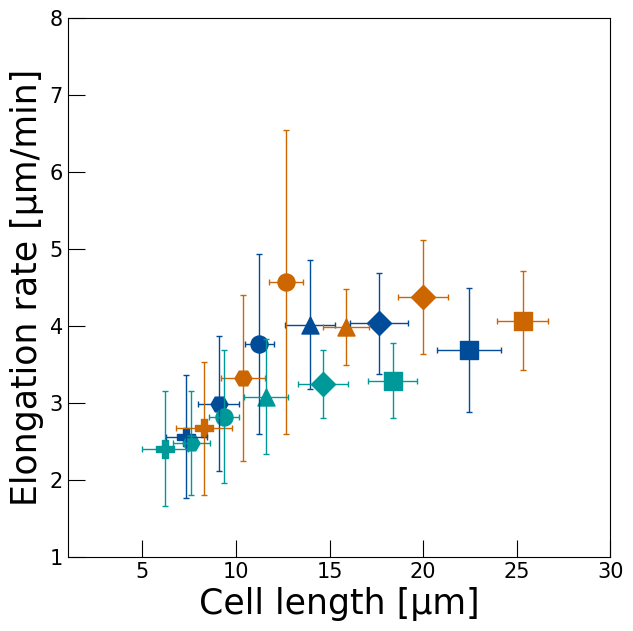

In [38]:
# define the plot style and size
sns.set_style(style=None)
plt.figure(figsize=(7,7))

'''WT Elongation rate: pole-to-pole distance'''
# sort the data
sorted_indices = np.argsort(x_WT)
x_WT_sorted = x_WT[sorted_indices]
y_WT_pp_elong_sorted = y_WT_pp_elong[sorted_indices]

# smooth line plot
x_smooth = np.linspace(min(x_WT_sorted), max(x_WT_sorted), 200)
spl = make_interp_spline(x_WT_sorted, y_WT_pp_elong_sorted, k=3)
y_smooth = spl(x_smooth)
# ax = plt.plot(x_smooth, y_smooth, color='#004C99')

# add error bars
plt.errorbar(x=x_WT, y=y_WT_pp_elong, xerr=x_WT_err, yerr=y_WT_pp_elong_err, capsize=2, elinewidth=1, fmt='none', color='#004C99')

# add markers
for x_val, y_val, marker_val in zip(x_WT, y_WT_pp_elong, marker):
    plt.scatter(x_val, y_val, marker=marker_val, color='#004C99', s=150)

# add legend
reg_line_pp_WT = plt.Line2D([], [], color='#004C99', marker='', markersize=5, label='Wild type', linewidth=5)
# plt.legend(handles=[reg_line_cc_WT])


'''big Elongation rate: pole-to-pole distance'''
# sort the data
sorted_indices = np.argsort(x_big)
x_big_sorted = x_big[sorted_indices]
y_big_pp_elong_sorted = y_big_pp_elong[sorted_indices]

# smooth line plot
x_smooth = np.linspace(min(x_big_sorted), max(x_big_sorted), 200)
spl = make_interp_spline(x_big_sorted, y_big_pp_elong_sorted, k=3)
y_smooth = spl(x_smooth)
# ax = plt.plot(x_smooth, y_smooth, color='#CC6600')

# Add error bars
plt.errorbar(x=x_big, y=y_big_pp_elong, xerr=x_big_err, yerr=y_big_pp_elong_err, capsize=2, elinewidth=1, fmt='none', color='#CC6600')

# add markers
for x_val, y_val, marker_val in zip(x_big, y_big_pp_elong, marker):
    plt.scatter(x_val, y_val, marker=marker_val, color='#CC6600', s=150)

# add legend
reg_line_pp_big = plt.Line2D([], [], color='#CC6600', marker='', markersize=5, label='Big embryo', linewidth=5)
# plt.legend(handles=[reg_line_cc_big])


'''small Elongation rate: pole-to-pole distance'''
# sort the data
sorted_indices = np.argsort(x_small)
x_small_sorted = x_small[sorted_indices]
y_small_pp_elong_sorted = y_small_pp_elong[sorted_indices]

# smooth line plot
x_smooth = np.linspace(min(x_small_sorted), max(x_small_sorted), 200)
spl = make_interp_spline(x_small_sorted, y_small_pp_elong_sorted, k=3)
y_smooth = spl(x_smooth)
# ax1 = plt.plot(x_smooth, y_smooth, color='#009999')

# Add error bars
plt.errorbar(x=x_small, y=y_small_pp_elong, xerr=x_small_err, yerr=y_small_pp_elong_err, capsize=2, elinewidth=1, fmt='none', color='#009999')

# add markers
for x_val, y_val, marker_val in zip(x_small, y_small_pp_elong, marker):
    plt.scatter(x_val, y_val, marker=marker_val, color='#009999', s=150)

# add legend
reg_line_pp_small = plt.Line2D([], [], color='#009999', marker='', markersize=5, label='Small embryo', linewidth=5)
# plt.legend(handles=[reg_line_cc_small])


# plot properties
plt.xlim(1, 30)
# plt.ylim(0, 25)
plt.ylim(1, 8)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)
plt.xlabel('Cell length [µm]', fontsize=25)
plt.ylabel('Elongation rate [µm/min]', fontsize=25)
# plt.legend(handles=[reg_line_pp_WT, reg_line_pp_big, reg_line_pp_small])
plt.gca().tick_params(axis='x', labelsize=15)
plt.gca().tick_params(axis='y', labelsize=15)
plt.gca().tick_params(axis='both', which='major', labelsize=15)
plt.gca().tick_params(axis='x', direction='in', size=12)
plt.gca().tick_params(axis='y', direction='in', size=12)

# plt.savefig(os.path.join(save_files, 'Elongation pole_to_pole.png'), dpi=600)
# plt.savefig(os.path.join(save_files, 'Elongation pole_to_pole.svg'), dpi=600)

# plt.savefig(os.path.join(save_files, 'Elongation  (zoomed_in).png'), dpi=600)
# plt.savefig(os.path.join(save_files, 'Elongation pole_to_pole (zoomed_in).svg'), dpi=600)

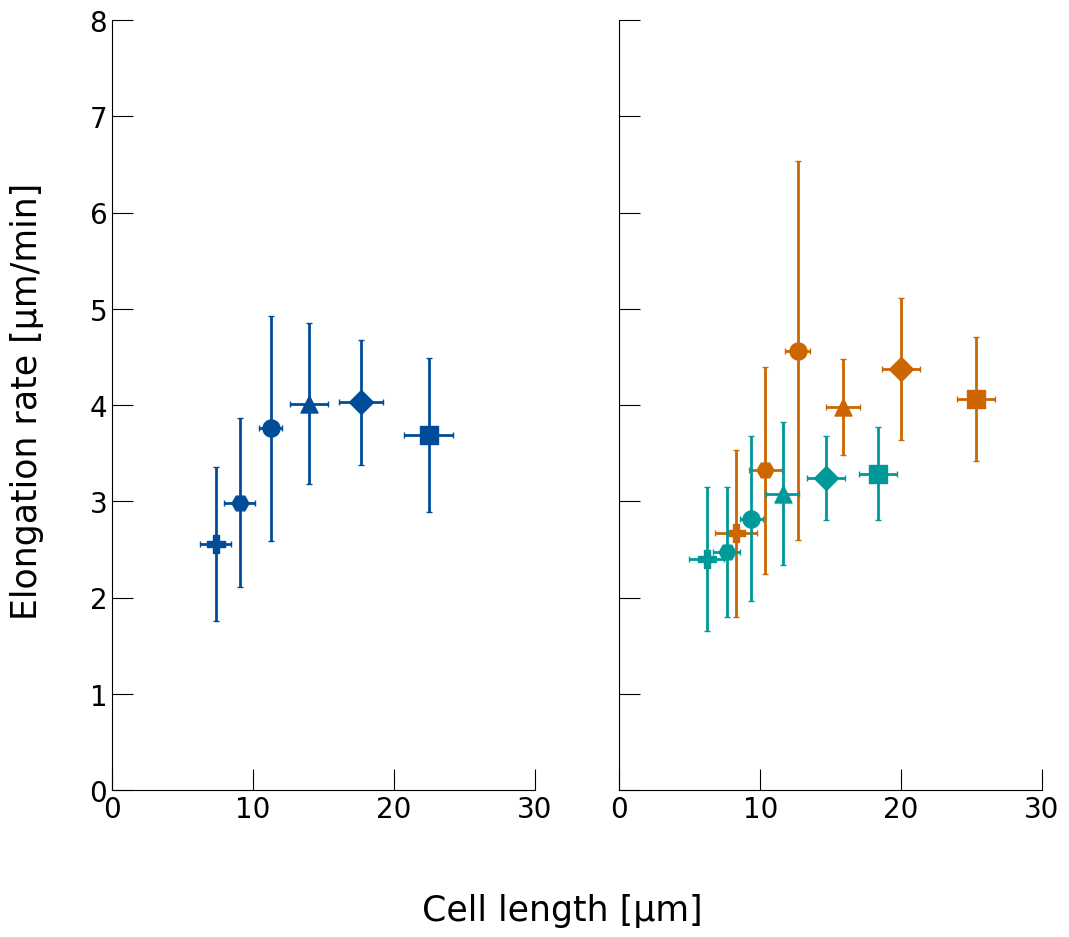

In [39]:
''' Making a subplot for elongation rate for each embryo type'''
# define the plot style and size
sns.set_style(style=None)
fig, axs = plt.subplots(1, 2, figsize=(12, 10), sharey=True)

def plot_embryo(ax, x, y, x_err, y_err, marker, color, label):
    # sort the data
    sorted_indices = np.argsort(x)
    x_sorted = x[sorted_indices]
    y_sorted = y[sorted_indices]

    # smooth line plot
    # x_smooth = np.linspace(min(x_sorted), max(x_sorted), 200)
    # spl = make_interp_spline(x_sorted, y_sorted, k=3)
    # y_smooth = spl(x_smooth)
    # ax.plot(x_smooth, y_smooth, color=color)

    # add error bars
    ax.errorbar(x=x, y=y, xerr=x_err, yerr=y_err, capsize=2, elinewidth=2, fmt='none', color=color)

    # add markers
    for x_val, y_val, marker_val in zip(x, y, marker):
        ax.scatter(x_val, y_val, marker=marker_val, color=color, s=150)

    # add legend
    ax.plot([], [], color=color, marker='', markersize=5, label=label, linewidth=5)

# wild type
plot_embryo(axs[0], x_WT, y_WT_pp_elong, x_WT_err, y_WT_pp_elong_err, marker, '#004C99', 'Wild type')
# axs[0].set_title('Wild Type')

# big embryo
plot_embryo(axs[1], x_big, y_big_pp_elong, x_big_err, y_big_pp_elong_err, marker, '#CC6600', 'Big embryo')
# axs[1].set_title('Big Embryo')

# small embryo
plot_embryo(axs[1], x_small, y_small_pp_elong, x_small_err, y_small_pp_elong_err, marker, '#009999', 'Small embryo')
# axs[1].set_title('Small Embryo')

# set common properties for all subplots
for ax in axs:
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 8)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.tick_params(axis='both', which='major', direction='in', size=15, labelsize=20)
    
    # show only the left and bottom spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

# add shared axis labels
fig.text(0.5, -0.02,
         'Cell length [µm]',
         ha='center',
         fontsize=25)

fig.text(0.04, 0.5,
         'Elongation rate [µm/min]',
         va='center',
         rotation='vertical',
         fontsize=25)

# plt.tight_layout(rect=[0.1, 0.1, .95, .95])
plt.show()

for ax in axs:
    ax.figure.savefig(os.path.join(save_files, 'Elongation  (splitted).png'), dpi=600, bbox_inches='tight')
    ax.figure.savefig(os.path.join(save_files, 'Elongation pole_to_pole (splitted).svg'), dpi=600, bbox_inches='tight')

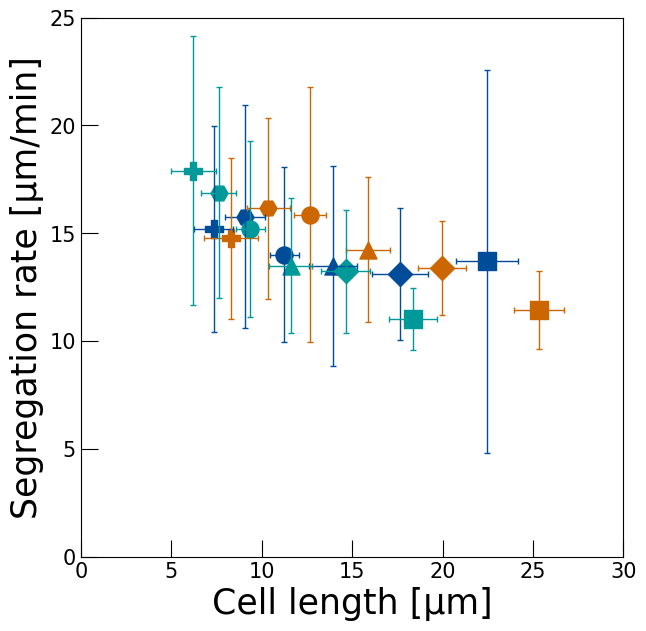

In [40]:
# define the plot stle and size
sns.set_style(style=None)
plt.figure(figsize=(7,7))

'''WT Segregation rate: pole-to-pole distance'''
# sort the data
sorted_indices = np.argsort(x_WT)
x_WT_sorted = x_WT[sorted_indices]
y_WT_cc_segreg_sorted = y_WT_cc_segreg[sorted_indices]

# smooth line plot
x_smooth = np.linspace(min(x_WT_sorted), max(x_WT_sorted), 200)
spl = make_interp_spline(x_WT_sorted, y_WT_cc_segreg_sorted, k=3)
y_smooth = spl(x_smooth)
# ax = plt.plot(x_smooth, y_smooth, color='#004C99')

# Add error bars
plt.errorbar(x=x_WT, y=y_WT_cc_segreg, xerr=x_WT_err, yerr=y_WT_cc_segreg_err, capsize=2, elinewidth=1, fmt='none', color='#004C99')

# add markers
for x_val, y_val, marker_val in zip(x_WT, y_WT_cc_segreg, marker):
    plt.scatter(x_val, y_val, marker=marker_val, color='#004C99', s=150)

# add legend
reg_line_cc_WT = plt.Line2D([], [], color='#004C99', marker='', markersize=5, label='Wild type', linewidth=5)
# plt.legend(handles=[reg_line_cc_WT])


'''big Segregation rate: pole-to-pole distance'''
# sort the data
sorted_indices = np.argsort(x_big)
x_big_sorted = x_big[sorted_indices]
y_big_cc_segreg_sorted = y_big_cc_segreg[sorted_indices]

# smooth line plot
x_smooth = np.linspace(min(x_big_sorted), max(x_big_sorted), 200)
spl = make_interp_spline(x_big_sorted, y_big_cc_segreg_sorted, k=3)
y_smooth = spl(x_smooth)
# ax = plt.plot(x_smooth, y_smooth, color='#CC6600')

# Add error bars
plt.errorbar(x=x_big, y=y_big_cc_segreg, xerr=x_big_err, yerr=y_big_cc_segreg_err, capsize=2, elinewidth=1, fmt='none', color='#CC6600')

# add markers
for x_val, y_val, marker_val in zip(x_big, y_big_cc_segreg, marker):
    plt.scatter(x_val, y_val, marker=marker_val, color='#CC6600', s=150)

# add legend
reg_line_cc_big = plt.Line2D([], [], color='#CC6600', marker='', markersize=5, label='Big embryo', linewidth=5)
# plt.legend(handles=[reg_line_cc_big])


'''small Segregation rate: pole-to-pole distance'''
# sort the data
sorted_indices = np.argsort(x_small)
x_small_sorted = x_small[sorted_indices]
y_small_cc_segreg_sorted = y_small_cc_segreg[sorted_indices]

# smooth line plot
x_smooth = np.linspace(min(x_small_sorted), max(x_small_sorted), 200)
spl = make_interp_spline(x_small_sorted, y_small_cc_segreg_sorted, k=3)
y_smooth = spl(x_smooth)
# ax1 = plt.plot(x_smooth, y_smooth, color='#009999')

# Add error bars
plt.errorbar(x=x_small, y=y_small_cc_segreg, xerr=x_small_err, yerr=y_small_cc_segreg_err, capsize=2, elinewidth=1, fmt='none', color='#009999')

# add markers
for x_val, y_val, marker_val in zip(x_small, y_small_cc_segreg, marker):
    plt.scatter(x_val, y_val, marker=marker_val, color='#009999', s=150)

# add legend
reg_line_cc_small = plt.Line2D([], [], color='#009999', marker='', markersize=5, label='Small embryo', linewidth=5)
# plt.legend(handles=[reg_line_cc_small])


# plot properties
plt.xlim(0, 30)
plt.ylim(0, 25)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)
plt.xlabel('Cell length [µm]', fontsize=25)
plt.ylabel('Segregation rate [µm/min]', fontsize=25)
# plt.legend(handles=[reg_line_cc_WT, reg_line_cc_big, reg_line_cc_small])
plt.gca().tick_params(axis='x', labelsize=15)
plt.gca().tick_params(axis='y', labelsize=15)
plt.gca().tick_params(axis='both', which='major', labelsize=15)
plt.gca().tick_params(axis='x', direction='in', size=12)
plt.gca().tick_params(axis='y', direction='in', size=12)

plt.savefig(os.path.join(save_files, 'Segregation chromosome-to-chromosome.png'), dpi=600)
plt.savefig(os.path.join(save_files, 'Segregation chromosome-to-chromosome.svg'), dpi=600)

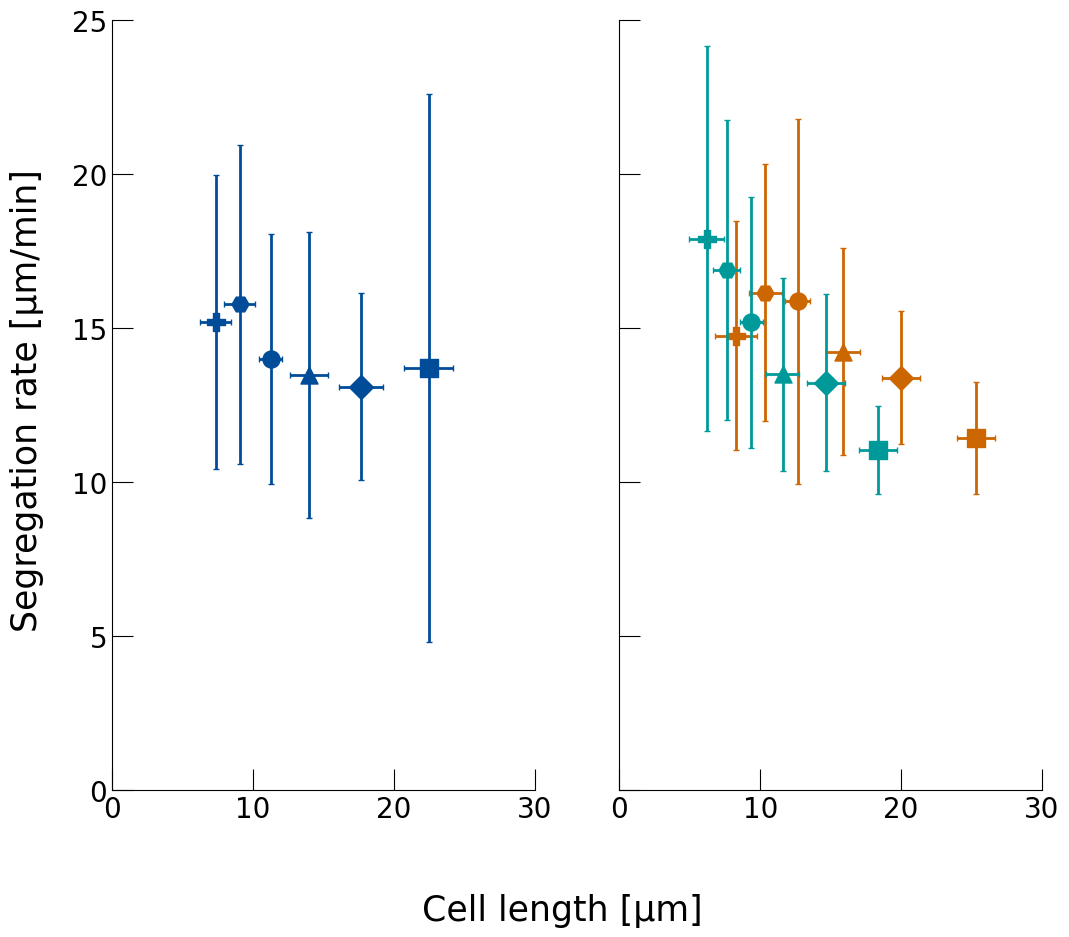

In [44]:
# define the plot style and size
sns.set_style(style=None)
fig, axs = plt.subplots(1, 2, figsize=(12, 10), sharey=True)

def plot_embryo(ax, x, y, x_err, y_err, marker, color, label):
    # sort the data
    sorted_indices = np.argsort(x)
    x_sorted = x[sorted_indices]
    y_sorted = y[sorted_indices]

    # smooth line plot
    # x_smooth = np.linspace(min(x_sorted), max(x_sorted), 200)
    # spl = make_interp_spline(x_sorted, y_sorted, k=3)
    # y_smooth = spl(x_smooth)
    # ax.plot(x_smooth, y_smooth, color=color)

    # add error bars
    ax.errorbar(x=x, y=y, xerr=x_err, yerr=y_err, capsize=2, elinewidth=2, fmt='none', color=color)

    # add markers
    for x_val, y_val, marker_val in zip(x, y, marker):
        ax.scatter(x_val, y_val, marker=marker_val, color=color, s=150)

    # add legend
    ax.plot([], [], color=color, marker='', markersize=5, label=label, linewidth=5)

# wild type
plot_embryo(axs[0], x_WT, y_WT_cc_segreg, x_WT_err, y_WT_cc_segreg_err, marker, '#004C99', 'Wild type')
# axs[0].set_title('Wild Type')

# big embryo
plot_embryo(axs[1], x_big, y_big_cc_segreg, x_big_err, y_big_cc_segreg_err, marker, '#CC6600', 'Big embryo')
# axs[1].set_title('Big Embryo')

# small embryo
plot_embryo(axs[1], x_small, y_small_cc_segreg, x_small_err, y_small_cc_segreg_err, marker, '#009999', 'Small embryo')
# axs[1].set_title('Small Embryo')

# set common properties for all subplots
for ax in axs:
    ax.set_xlim(0, 30)
    ax.set_ylim(0, 25)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.tick_params(axis='both', which='major', direction='in', size=15, labelsize=20)
    
    # show only the left and bottom spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    

# add shared axis labels
fig.text(0.5, -0.02,
         'Cell length [µm]',
         ha='center',
         fontsize=25)

fig.text(0.04, 0.5,
         'Segregation rate [µm/min]',
         va='center',
         rotation='vertical',
         fontsize=25)

# plt.tight_layout(rect=[0.1, 0.1, .95, .95])
plt.show()

for ax in axs:
    ax.figure.savefig(os.path.join(save_files, 'Segregation  (splitted).png'), dpi=600, bbox_inches='tight')
    ax.figure.savefig(os.path.join(save_files, 'Segregation pole_to_pole (splitted).svg'), dpi=600, bbox_inches='tight')